# DeepLense – Gravitational Lens Finding

This notebook implements a deep learning pipeline to detect strong gravitational lens systems in astronomical images.

Strong gravitational lensing occurs when a massive foreground galaxy bends the light of a distant galaxy, producing arc-like or ring-shaped structures.

Identifying these systems is important for studying:

- Dark matter distribution
- Galaxy evolution
- Cosmology

However, strong lenses are extremely rare in astronomical surveys, and the number of non-lensed galaxies is significantly larger.

This project applies machine learning to automatically detect gravitational lens candidates from observational survey data.

## Strategy

The goal is to build a model that distinguishes between:

- Lens
- Non-Lens

A Convolutional Neural Network (CNN) is used because CNNs are highly effective for extracting spatial features from images.

The model learns patterns associated with gravitational lensing such as arcs and rings.

Key steps in this workflow:

1. Load observational galaxy images
2. Preprocess and normalize image data
3. Train a CNN model
4. Evaluate model performance
5. Measure results using ROC curve and AUC score

These evaluation metrics are appropriate for imbalanced datasets where non-lensed galaxies significantly outnumber lens systems.

In [9]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_curve, auc

## Dataset Description

The dataset contains observational galaxy images with shape:

(3, 64, 64)

The three channels correspond to different telescope filters.

Dataset structure:

dataset/
│
├── train_lenses
├── train_nonlenses
│
├── test_lenses
└── test_nonlenses

In [10]:
class LensDataset(Dataset):

    def __init__(self, lens_dir, nonlens_dir):

        self.data = []
        self.labels = []

        # Lens images
        for file in os.listdir(lens_dir):
            if file.endswith(".npy"):
                self.data.append(os.path.join(lens_dir, file))
                self.labels.append(1)

        # Non-lens images
        for file in os.listdir(nonlens_dir):
            if file.endswith(".npy"):
                self.data.append(os.path.join(nonlens_dir, file))
                self.labels.append(0)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        img = np.load(self.data[idx]).astype(np.float32)

        img = torch.tensor(img)

        label = torch.tensor(self.labels[idx])

        return img, label

In [12]:
train_dataset = LensDataset(
    "lens-finding-test/train_lenses",
    "lens-finding-test/train_nonlenses"
)

test_dataset = LensDataset(
    "lens-finding-test/test_lenses",
    "lens-finding-test/test_nonlenses"
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 30405
Testing samples: 19650


# Example Image

### Data Visualization

Each object in the dataset contains three filters representing
different telescope observations.

Below we visualize examples of both gravitational lens systems
and non-lens galaxies across the three filters.

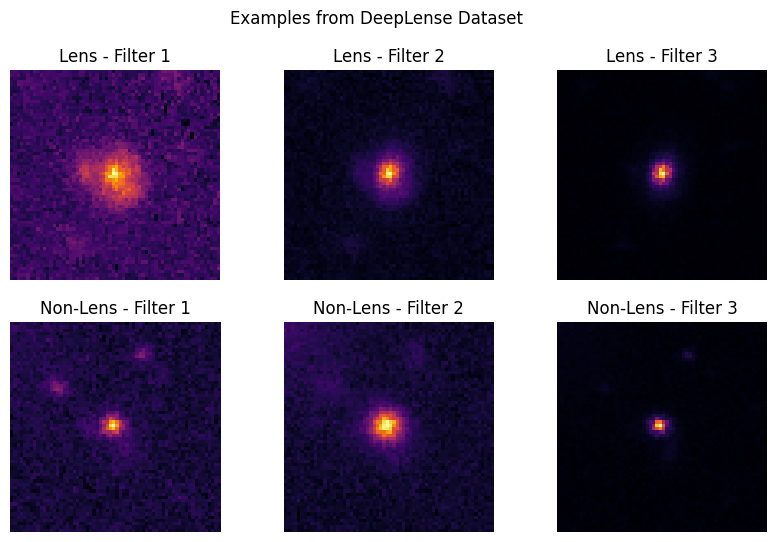

In [25]:
import matplotlib.pyplot as plt

# find one lens and one non-lens sample
lens_img = None
nonlens_img = None

for i in range(len(train_dataset)):
    
    img, label = train_dataset[i]
    
    if label == 1 and lens_img is None:
        lens_img = img
        
    if label == 0 and nonlens_img is None:
        nonlens_img = img
        
    if lens_img is not None and nonlens_img is not None:
        break


fig, axes = plt.subplots(2,3, figsize=(10,6))

# Lens row
for i in range(3):
    
    axes[0,i].imshow(lens_img[i], cmap="inferno")
    axes[0,i].set_title("Lens - Filter " + str(i+1))
    axes[0,i].axis("off")

# Non-Lens row
for i in range(3):
    
    axes[1,i].imshow(nonlens_img[i], cmap="inferno")
    axes[1,i].set_title("Non-Lens - Filter " + str(i+1))
    axes[1,i].axis("off")

plt.suptitle("Examples from DeepLense Dataset")

plt.show()

## Model Architecture

In [14]:
class LensCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64*8*8,128),
            nn.ReLU(),

            nn.Linear(128,2)
        )

    def forward(self,x):

        x = self.conv(x)
        x = self.fc(x)

        return x


model = LensCNN()

print(model)

LensCNN(
  (conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


## Training Setup

In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Training

In [16]:
epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", running_loss)

Epoch: 1 Loss: 72.31581505294889
Epoch: 2 Loss: 56.040265960618854
Epoch: 3 Loss: 50.59803374437615
Epoch: 4 Loss: 47.13559863809496
Epoch: 5 Loss: 43.05751387006603


## Model Evaluation

In [17]:
model.eval()

y_true = []
y_scores = []

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        probs = F.softmax(outputs, dim=1)

        y_true.extend(labels.numpy())

        y_scores.extend(probs[:,1].numpy())

## ROC Curve and AUC Score

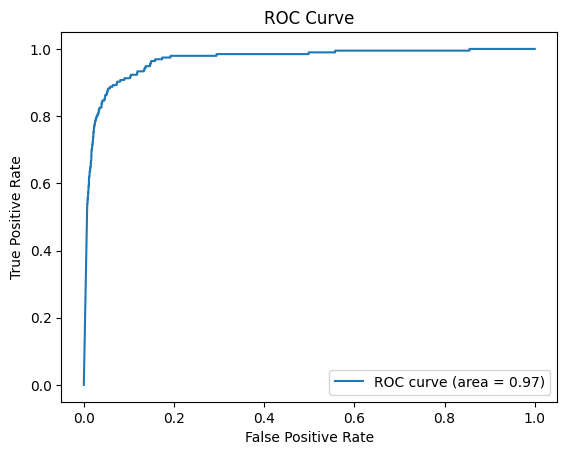

AUC Score: 0.9674320094366354


In [18]:
fpr, tpr, _ = roc_curve(y_true, y_scores)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC Score:", roc_auc)

## Save Model Weights

In [26]:
torch.save(model.state_dict(), "lens_finder_model.pth")